In [2]:
import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, AddHs, Draw
from rdkit.Chem.Draw import MolsToGridImage
import matplotlib.pyplot as plt
from pathlib import Path

drawer = Draw.rdMolDraw2D.MolDraw2DSVG(200, 200)
options = drawer.drawOptions()
options.legendFontSize = 24

# Data imports

In [3]:
cwd = Path.cwd()
project_root = cwd.parent

full_descriptor_path = project_root / 'outputs/aqme/QDESCP/raw_csv_databases/Raw_QDESCP_full_descriptors.csv'
descriptors_full = pd.read_csv(full_descriptor_path)

smiles_path = project_root / 'outputs/aqme/smiles_aqme.csv'
smiles_df = pd.read_csv(smiles_path)
smiles_df['mol'] = smiles_df['SMILES'].apply(Chem.MolFromSmiles)

# Add hydrogens to the molecules
smiles_df['mol'] = smiles_df['mol'].apply(AddHs)

# Lists are saved as strings, so we need to convert them back to lists
def str_to_list(val):
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            return ast.literal_eval(val)
        except Exception:
            return val
    return val

descriptors_full = descriptors_full.map(str_to_list)

In [4]:
type(descriptors_full.iloc[6,6])

list

In [5]:
# Filter the df to only include columns containing list values
is_list_col = descriptors_full.map(lambda x: isinstance(x, list)).any()
descriptors_list = descriptors_full.loc[:, is_list_col]
descriptors_list = pd.concat([descriptors_full['code_name'], descriptors_list], axis=1, ignore_index=True)
descriptors_list.columns = descriptors_full.columns[:len(descriptors_list.columns)]

# Reorder alphabetically
descriptors_list = descriptors_list.sort_values('code_name').reset_index(drop=True)

# Remove the suffix from the code_name
descriptors_list['code_name'] = descriptors_list['code_name'].apply(lambda x: x.split('_')[0])

In [6]:
descriptors_list.head()

,code_name,Partial charge,Electrophil.,Nucleophil.,Radical attack,SASA,Buried volume,H bond with H2O,s proportion,p proportion,...,Nu_Electrophil.,Nu_Nucleophil.,Nu_Radical attack,Disp. coeff. C6,Born radii,Cone angle,Solid angle,FOD s proportion,FOD p proportion,FOD d proportion
0,Bifonazole,"[-0.022, 0.033, 0.0028, -0.034800000000000005,...","[-0.0039000000000000003, -0.0027, 0.0371, 0.01...","[0.0413, 0.0413, 0.0413, 0.0413, 0.0413, 0.041...","[0.011600000000000001, -0.0046, 0.028, 0.0102,...","[0.0013000000000000002, 0.0, 0.6408, 7.471, 11...","[0.4551, 0.7028, 0.7196, 0.7184, 0.5664, 0.525...","[0.0, 0.0, 0.0, -0.0005, -0.001, 0.0, 0.0, -0....","[1.447, 1.0311, 1.0647, 1.05, 1.0495, 1.0653, ...","[3.7184, 2.8586, 2.9961, 3.0025, 3.0073, 2.968...",...,"[-0.0049, -0.0034000000000000002, 0.0466, 0.01...","[0.0339, -0.0082, 0.024200000000000003, 0.0094...","[0.0145, -0.0058000000000000005, 0.0351, 0.012...","[21.668, 20.0241, 27.9605, 28.8667, 28.8303, 2...","[2.7504, 2.9049, 2.8816, 2.6395, 2.6135, 2.792...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0009000000000000001, 0.0, 0.0, 0.0, 0.0, 0....","[0.003, 0.001, 0.0108, 0.0061, 0.008, 0.0095, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Boscalid,"[-0.41590000000000005, 0.277, -0.161, 0.072000...","[0.1076, 0.0367, 0.0262, 0.0131, 0.0105, 0.024...","[0.0551, 0.0551, 0.0551, 0.0551, 0.0551, 0.055...","[0.09970000000000001, 0.0236, 0.0354, 0.021, 0...","[28.1914, 7.0661, 0.7103, 5.3004999999999995, ...","[0.31720000000000004, 0.4299, 0.6141, 0.7088, ...","[-0.002, -0.001, 0.0, 0.0, -0.001, -0.001, -0....","[1.724, 0.966, 1.422, 1.033, 1.058, 1.047, 1.0...","[4.8759, 2.5929, 3.91, 2.834, 3.004, 3.01, 3.0...",...,"[0.0796, 0.027200000000000002, 0.0194, 0.0097,...","[0.067, 0.0078000000000000005, 0.033, 0.021400...","[0.0738, 0.0175, 0.0262, 0.0155, 0.0097, 0.020...","[22.0064, 22.3137, 24.487, 26.3801, 29.158, 28...","[2.123, 2.567, 2.5019, 2.813, 2.578, 2.49, 2.4...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029, 0.014, 0.014, 0.011, 0.012, 0.00900000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Caffeine,"[-0.441, 0.314, -0.117, 0.264, -0.436, -0.042,...","[0.0742, 0.008, 0.038900000000000004, 0.061, 0...","[0.061, 0.061, 0.061, 0.061, 0.061, 0.061, 0.0...","[0.0857, 0.0053, 0.0371, 0.0345, 0.1131, -0.02...","[30.9088, 9.0802, 1.52, 8.4802, 28.9089, 17.16...","[0.3524, 0.39940000000000003, 0.589, 0.6178, 0...","[-0.002, -0.001, 0.0, -0.001, -0.002, 0.0, 0.0...","[1.721, 0.9380000000000001, 1.444, 0.944000000...","[4.909, 2.528, 3.854, 2.69, 4.948, 2.953000000...",...,"[0.0979, 0.0105, 0.051300000000000005, 0.0804,...","[0.1282, 0.0023, 0.0455, 0.0105, 0.1282, -0.02...","[0.1131, 0.007, 0.049, 0.0455, 0.1492, -0.0303...","[22.509, 21.668, 23.549, 22.553, 22.409, 21.46...","[2.101, 2.5789999999999997, 2.466, 2.575, 2.09...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.007, 0.002, 0.005, 0.011, 0.016, 0.001, 0.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Camptothecin,"[-0.4617, 0.2529, -0.059800000000000006, 0.010...","[0.0935, 0.0098, 0.0771, 0.0453, 0.0, 0.0081, ...","[0.0492, 0.0492, 0.0492, 0.0492, 0.0492, 0.049...","[0.1212, 0.0114, 0.0704, 0.033800000000000004,...","[34.0865, 8.1127, 3.1121, 1.682, 0.0, 19.2302,...","[0.3658, 0.3876, 0.5919, 0.6979000000000001, 0...","[-0.003, -0.001, 0.0, 0.0, 0.0, -0.001, 0.0, 0...","[1.728, 0.974, 1.07, 1.0782, 1.0421, 1.6981000...","[4.895, 2.578, 3.1048, 2.9351000000000003, 2.7...",...,"[0.047900000000000005, 0.005, 0.0395, 0.023200...","[0.0763, 0.0059, 0.0327, 0.0115, 0.005, 0.0257...","[0.0621, 0.0059, 0.0361, 0.0173, 0.0025, 0.014...","[22.95, 22.7528, 29.485, 27.7697, 18.6935, 21....","[2.1017, 2.6

In [7]:
smiles_df.head()

,SMILES,code_name,mol
0,N1(C(C2=CC=C(C3=CC=CC=C3)C=C2)C4=CC=CC=C4)C=CN=C1,Bifonazole,<rdkit.Chem.rdchem.Mol object at 0x000001D9683...
1,O=C(NC1=CC=CC=C1C2=CC=C(Cl)C=C2)C3=CC=CN=C3Cl,Boscalid,<rdkit.Chem.rdchem.Mol object at 0x000001D9683...
2,O=C(N(C1=O)C)N(C2=C1N(C=N2)C)C,Caffeine,<rdkit.Chem.rdchem.Mol object at 0x000001D9683...
3,O=C1C2=C([C@@](O)(CC)C(OC2)=O)C=C(N1C3)C(C3=C4...,Camptothecin,<rdkit.Chem.rdchem.Mol object at 0x000001D9683...
4,CN/C(NCCSCC1=C(C)NC=N1)=N\C#N,Cimetadine,<rdkit.Chem.rdchem.Mol object at 0x000001D9683...


In [8]:
print(descriptors_list.columns)

Index(['code_name', 'Partial charge', 'Electrophil.', 'Nucleophil.',
       'Radical attack', 'SASA', 'Buried volume', 'H bond with H2O',
       's proportion', 'p proportion', 'd proportion', 'Coord. numbers',
       'Polariz. alpha', 'FOD', 'Dispersion', 'Pyramidalization',
       'Pyramidaliz. volume', 'fukui+', 'fukui-', 'fukui0', 'dual descrip.',
       'softness+', 'softness-', 'softness0', 'Rel. nucleophilicity',
       'Rel. electrophilicity', 'GC Dual Descrip.', 'Mult. descrip.',
       'Nu_Electrophil.', 'Nu_Nucleophil.', 'Nu_Radical attack',
       'Disp. coeff. C6', 'Born radii', 'Cone angle', 'Solid angle',
       'FOD s proportion', 'FOD p proportion', 'FOD d proportion'],
      dtype='object')


## Indexing investigations

In [9]:
mol = smiles_df['mol'][0]
num_atoms = mol.GetNumAtoms()
len_descriptors = len(descriptors_list.iloc[0,3])
print(f'Number of atoms for {smiles_df.loc[0, 'code_name']} in mol is {num_atoms}')
print(f'Length of {descriptors_list.loc[0, 'code_name']} descriptor lists is {len_descriptors}')  # Exclude 'code_name'

Number of atoms for Bifonazole in mol is 42
Length of Bifonazole descriptor lists is 42


In [10]:
def get_max_index(df, col_name):
    """Get the maximum index from the list in the specified column."""
    values = df[col_name].apply(lambda x: [int(np.argmax(x))] if isinstance(x, list) and len(x) > 0 else [])
    return values.tolist()

Highlight lists: [[22], [13], [0], [0], [6], [20], [4], [19], [0], [10], [9], [15], [6], [10], [11], [11], [7], [11], [8], [15], [11], [16], [0], [15], [12], [5], [24], [0], [20], [21], [13]]


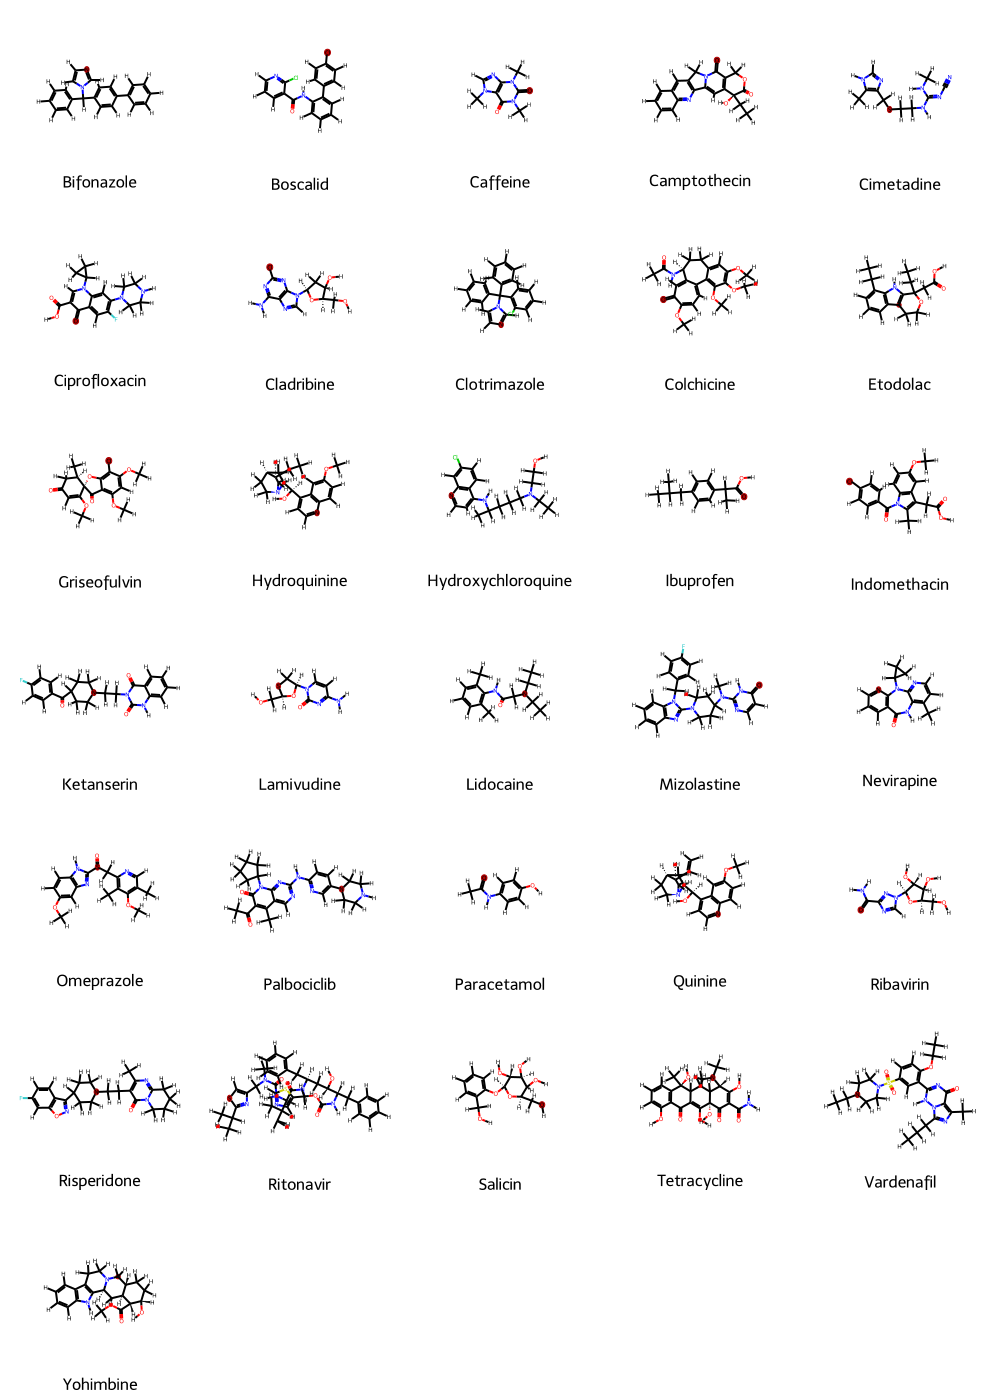

In [11]:
# Highlight the maximum index in the specified descripptor
value_to_highlight = 'Nu_Nucleophil.'

if value_to_highlight not in descriptors_list.columns:
    raise ValueError(f"Column '{value_to_highlight}' not found in descriptors_list.")

highlight_lists = get_max_index(descriptors_list, value_to_highlight)
print(f'Highlight lists: {highlight_lists}')

deep_red = (0.7, 0, 0)  # Example deep red color
highlight_colors = [{lst[0]: deep_red} for lst in highlight_lists]

img = MolsToGridImage(
    smiles_df['mol'].tolist(),
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=smiles_df['code_name'].tolist(),
    useSVG=True,
    highlightAtomLists=highlight_lists,
    highlightAtomColors=highlight_colors  # This draws a colored circle around the atom
)
img

Atoms selected as the most nucleophilic tended to be heteroatoms. Potentially more useful would be information about the most nucleophilic aromatic carbon bonded to a hydrogen...

In [12]:
# Function to find aromatic carbons with a bonded hydrogen
def aromatic_carbons_with_CH(mol):
    return [
        idx for idx in range(mol.GetNumAtoms())
        if (
            mol.GetAtomWithIdx(idx).GetSymbol() == 'C' # Carbon atom
            and mol.GetAtomWithIdx(idx).GetIsAromatic() # Aromatic carbon
            and mol.GetAtomWithIdx(idx).GetTotalNumHs(includeNeighbors=True) > 0 # Aromatic carbon a bonded hydrogen
        )
    ]

Aromatic carbons with CH of Ciprofloxacin: [4, 7, 17]


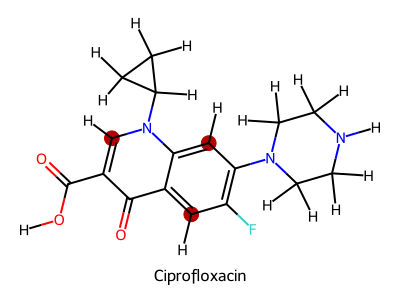

In [48]:
mol_index = 5 # The index of the molecule, not the atoms

mol = smiles_df['mol'][mol_index]
atom_indices = aromatic_carbons_with_CH(mol)
print(f'Aromatic carbons with CH of {smiles_df.loc[mol_index, "code_name"]}: {atom_indices}')

atom_labels = {idx: str(idx) for idx in atom_indices}
img = Draw.MolToImage(
    mol,
    size=(400, 300),
    legend=smiles_df.loc[mol_index, "code_name"],
    highlightAtoms=atom_indices,  
    highlightColor=(0.7, 0, 0)           
)
img

In [41]:
# Extract the values corresponding to the highlighted atoms
def extract_max_ch_value(mol, values, n_top=1):
    atom_indices = aromatic_carbons_with_CH(mol)
    ch_values = [values[idx] for idx in atom_indices]
    maxs = np.argsort(ch_values)[-n_top:][::-1]
    return [atom_indices[i] for i in maxs]

def extract_min_ch_value(mol, values, n_top=1):
    atom_indices = aromatic_carbons_with_CH(mol)
    ch_values = [values[idx] for idx in atom_indices]
    mins = np.argsort(ch_values)[:n_top]
    return [atom_indices[i] for i in mins]

def get_max_ch_index(df, col_name, n_top=1):
    indices = []
    for i, row in df.iterrows():
        index = extract_max_ch_value(smiles_df.loc[i,'mol'], row[col_name], n_top)
        indices.append(index)
    return indices

def get_min_ch_index(df, col_name, n_top=1):
    indices = []
    for i, row in df.iterrows():
        index = extract_min_ch_value(smiles_df.loc[i,'mol'], row[col_name], n_top)
        indices.append(index)
    return indices

Highlight lists: [[9], [6], [10], [12], [12], [7], [9], [7], [2], [5], [6], [18], [4], [4], [20], [22], [13], [3], [5], [17], [22], [12], [6], [18], [7], [20], [8], [15], [2], [13], [8]]


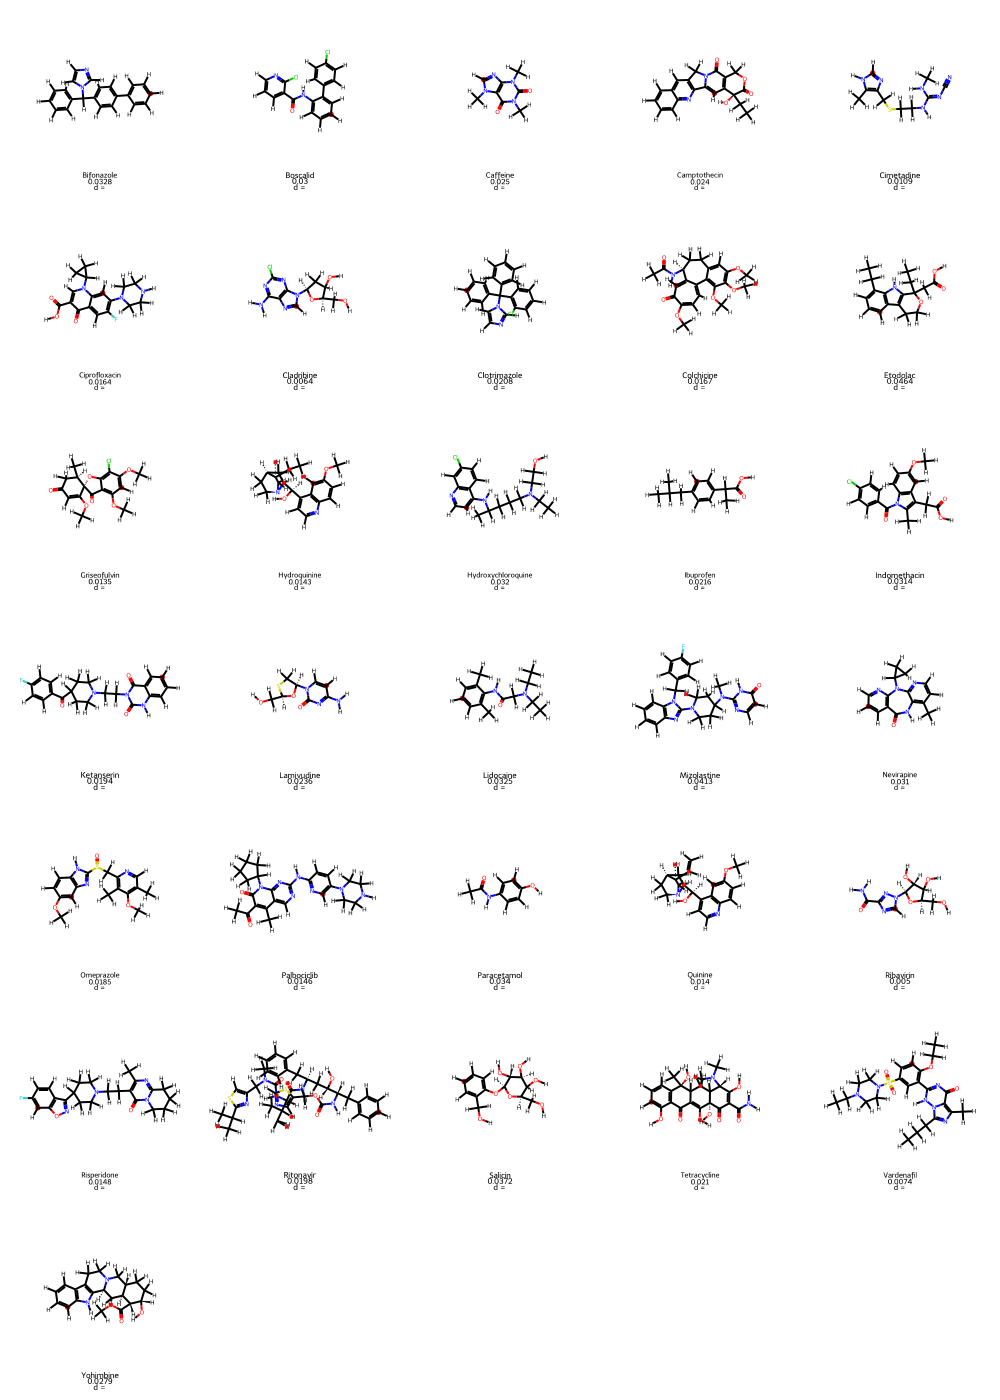

In [28]:
# Highlight the maximum index in the specified descripptor
value_to_highlight = 'fukui-'

if value_to_highlight not in descriptors_list.columns:
    raise ValueError(f"Column '{value_to_highlight}' not found in descriptors_list.")

highlight_lists = get_max_ch_index(descriptors_list, value_to_highlight)
print(f'Highlight lists: {highlight_lists}')

color = (1, 0, 0)
highlight_colors = [{lst[0]: color} for lst in highlight_lists]

max_values = [descriptors_list.loc[x, value_to_highlight][lst[0]] for x, lst in enumerate(highlight_lists)]
second_max_values = [descriptors_list.loc[x, value_to_highlight][lst[1]] if len(lst) > 1 else None for x, lst in enumerate(highlight_lists)]

lables = [
    f'{x}\n{np.round(y, 5)}\n{np.round(z, 5) if z is not None else ""}\nd = {np.round(abs(y - z), 5) if z is not None else ""}'
    for x, y, z in zip(smiles_df['code_name'], max_values, second_max_values)
]

img = MolsToGridImage(
    smiles_df['mol'].tolist(),
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=lables,
    useSVG=True,
    highlightAtomLists=highlight_lists,
    highlightAtomColors=highlight_colors,
    #removeHs=True
)
img

Atoms selected tended to be the most reactive within the investigated system, and could potentially lead to regioselectivity predictions. When selecting the top 2, the site of reactivity in the formation of major products was encapsulated for all successful substrates, with the exception of ritonavir, where the phenyl moiety was selected as being more nucleophilic than the thioazole, and colchicine, where the propone moiety was selected as being more nucleophilic than the phenyl.

A set of descriptors describing the aromatic C-H carbon atom with the calculated highest nucleophilicity would be simpliler to impliment for predictions (only requiring the structure of the substrate), but descriptors describing the actual site of C-H reactivity may be a better set of descriptors for prediction. However, this would require knowledge of both the starting material and product.

## Finding the indexes of the halogenated carbons for the major product of each testing set

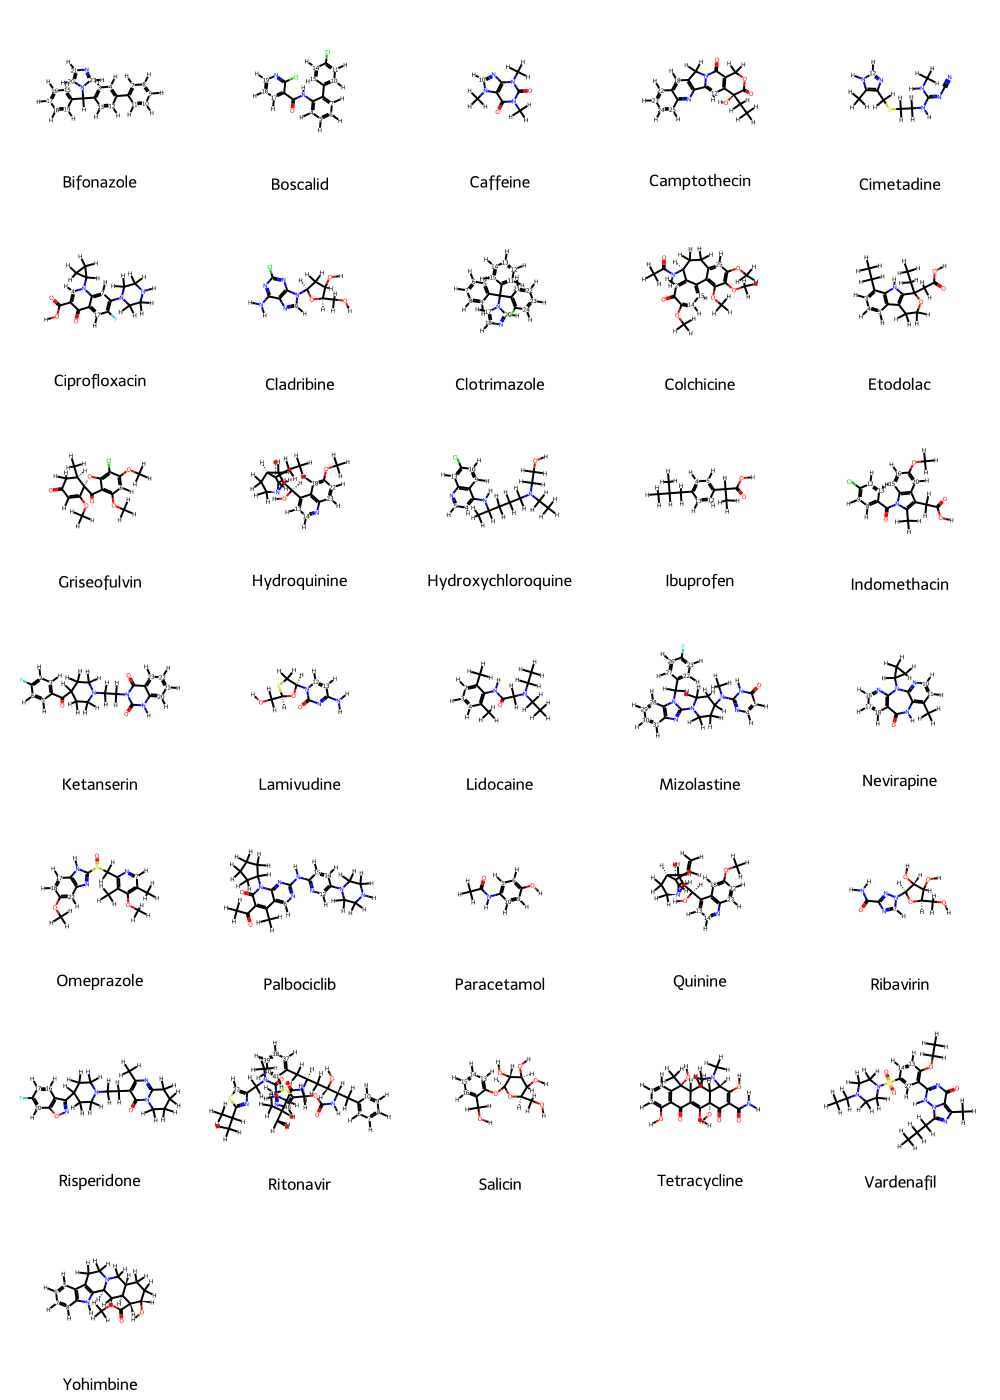

In [20]:
labeled_mols = []
for mol in smiles_df['mol']:
    mol = Chem.Mol(mol)  # Copy molecule
    for idx in aromatic_carbons_with_CH(mol):
        mol.GetAtomWithIdx(idx).SetProp("_displayLabel", str(idx))
    labeled_mols.append(mol)

img = MolsToGridImage(
    labeled_mols,
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=smiles_df['code_name'].tolist(),
    useSVG=True,
)
img

In [ ]:
# List of halogenated substrates with their halogenated carbon index. Nan denotes no halogenated carbon experimentally observed in HTE
halogenated_carbons = [{'code_name': 'Bifonazole', 'halogenated_index': 9},
                       {'code_name': 'Boscalid', 'halogenated_index': 6},
                       {'code_name': 'Caffeine', 'halogenated_index': 10},
                       {'code_name': 'Camptothecin', 'halogenated_index': 12},
                       {'code_name': 'Cimetadine', 'halogenated_index': np.nan},
                       {'code_name': 'Ciprofloxacin', 'halogenated_index': 7},
                       {'code_name': 'Cladribine', 'halogenated_index': np.nan},
                       {'code_name': 'Clotrimazole', 'halogenated_index': np.nan},
                       {'code_name': 'Colchicine', 'halogenated_index': 25},
                       {'code_name': 'Etodolac', 'halogenated_index': np.nan},
                       {'code_name': 'Griseofulvin', 'halogenated_index': 6},
                       {'code_name': 'Hydroquinine', 'halogenated_index': 18},
                       {'code_name': 'Hydroxychloroquine', 'halogenated_index': 4},
                       {'code_name': 'Ibuprofen', 'halogenated_index': 4},
                       {'code_name': 'Indomethacin', 'halogenated_index': 16},
                       {'code_name': 'Ketanserin', 'halogenated_index': 22},
                       {'code_name': 'Lamivudine', 'halogenated_index': np.nan},
                       {'code_name': 'Lidocaine', 'halogenated_index': 2},
                       {'code_name': 'Mizolastine', 'halogenated_index': 5},
                       {'code_name': 'Nevirapine', 'halogenated_index': 11},
                       {'code_name': 'Omeprazole', 'halogenated_index': np.nan},
                       {'code_name': 'Palbociclib', 'halogenated_index': 12},
                       {'code_name': 'Paracetamol', 'halogenated_index': 6},
                       {'code_name': 'Quinine', 'halogenated_index': 18},
                       {'code_name': 'Ribavirin', 'halogenated_index': np.nan},
                       {'code_name': 'Risperidone', 'halogenated_index': 17},
                       {'code_name': 'Ritonavir', 'halogenated_index': 23},
                       {'code_name': 'Salicin', 'halogenated_index': 15},
                       {'code_name': 'Tetracycline', 'halogenated_index': np.nan},
                       {'code_name': 'Vardenafil', 'halogenated_index': 13},
                       {'code_name': 'Yohimbine', 'halogenated_index': 6},
                       ]

In [33]:
ch_index_df = pd.DataFrame(halogenated_carbons)
ch_index_df.shape

(31, 2)

# What max/min descriptor is the best predictor of regiochemistry

In [34]:
list_columns = descriptors_list.columns[1:]
list_columns  # Exclude 'code_name' and 'code_name' column

Index(['Partial charge', 'Electrophil.', 'Nucleophil.', 'Radical attack',
       'SASA', 'Buried volume', 'H bond with H2O', 's proportion',
       'p proportion', 'd proportion', 'Coord. numbers', 'Polariz. alpha',
       'FOD', 'Dispersion', 'Pyramidalization', 'Pyramidaliz. volume',
       'fukui+', 'fukui-', 'fukui0', 'dual descrip.', 'softness+', 'softness-',
       'softness0', 'Rel. nucleophilicity', 'Rel. electrophilicity',
       'GC Dual Descrip.', 'Mult. descrip.', 'Nu_Electrophil.',
       'Nu_Nucleophil.', 'Nu_Radical attack', 'Disp. coeff. C6', 'Born radii',
       'Cone angle', 'Solid angle', 'FOD s proportion', 'FOD p proportion',
       'FOD d proportion'],
      dtype='object')

In [43]:
# Create a new DataFrames with the indicies of the 2 maximum and 2 minimum values for each descriptor

for column in list_columns:
    column_name_max = f'{column}_ch_max'
    column_name_min = f'{column}_ch_min'

    output_max = get_max_ch_index(descriptors_list, column, n_top=2)
    output_min = get_min_ch_index(descriptors_list, column, n_top=2)

    values_max = [x[:] for x in output_max]
    values_min = [x[:] for x in output_min]

    ch_index_df[column_name_max] = values_max
    ch_index_df[column_name_min] = values_min

ch_index_df.head()

,code_name,halogenated_index,Partial charge_ch_max,Partial charge_ch_min,Electrophil._ch_max,Electrophil._ch_min,Nucleophil._ch_max,Nucleophil._ch_min,Radical attack_ch_max,Radical attack_ch_min,...,Cone angle_ch_max,Cone angle_ch_min,Solid angle_ch_max,Solid angle_ch_min,FOD s proportion_ch_max,FOD s proportion_ch_min,FOD p proportion_ch_max,FOD p proportion_ch_min,FOD d proportion_ch_max,FOD d proportion_ch_min
0,Bifonazole,9.0,"[23, 21]","[3, 13]","[9, 17]","[23, 20]","[23, 12]","[3, 20]","[9, 17]","[23, 20]",...,"[23, 12]","[3, 20]","[23, 12]","[3, 20]","[23, 12]","[3, 20]","[9, 12]","[8, 10]","[23, 12]","[3, 20]"
1,Boscalid,6.0,"[19, 17]","[4, 18]","[19, 17]","[15, 14]","[19, 18]","[4, 5]","[6, 19]","[15, 14]",...,"[14, 19]","[4, 5]","[14, 19]","[4, 5]","[19, 18]","[4, 5]","[19, 17]","[7, 10]","[19, 18]","[4, 5]"
2,Caffeine,10.0,[10],[10],[10],[10],[10],[10],[10],[10],...,[10],[10],[10],[10],[10],[10],[10],[10],[10],[10]
3,Camptothecin,12.0,"[24, 23]","[12, 25]","[18, 23]","[12, 24]","[25, 24]","[12, 18]","[23, 12]","[22, 24]",...,"[25, 24]","[12, 18]","[25, 24]","[12, 18]","[25, 24]","[12, 18]","[18, 12]","[24, 23]","[25, 24]","[12, 18]"
4,Cimetadine,NaN,[12],[12],[12],[12],[12],[12],[12],[12],...,[12],[12],[12],[12],[12],[12],[12],[12],[12],[12]


# How often does each descriptor successfully identify the halogenated carbon from the scope?

In [46]:
# Filter the DataFrame to only include successfully halogenated substrates and calculate the F values

halogenated_substrates_df = ch_index_df[ch_index_df['halogenated_index'].notna()]

f_values = []

for column in halogenated_substrates_df.columns[2:]:
    truth_list = [x == y[0] for x, y in zip(halogenated_substrates_df['halogenated_index'], halogenated_substrates_df[column])]
    f_value = sum(truth_list) / len(truth_list)
    f_values.append(f_value)

f_values_df = pd.DataFrame({
    'descriptor': halogenated_substrates_df.columns[2:],
    'f_value': f_values
})
f_values_df = f_values_df.sort_values('f_value', ascending=False).reset_index(drop=True)
f_values_df.head(10)
    
    

,descriptor,f_value
0,Nu_Nucleophil._ch_max,0.695652
1,fukui-_ch_max,0.695652
2,dual descrip._ch_min,0.652174
3,Mult. descrip._ch_min,0.652174
4,softness-_ch_max,0.652174
5,GC Dual Descrip._ch_min,0.608696
6,p proportion_ch_max,0.608696
7,softness+_ch_min,0.608696
8,Nu_Electrophil._ch_min,0.608696
9,Polariz. alpha_ch_max,0.565217


# Is the correct index ranked in the top 2 selected indexes for each descriptor?

In [47]:
f_values = []

for column in halogenated_substrates_df.columns[2:]:
    truth_list = [x in y for x, y in zip(halogenated_substrates_df['halogenated_index'], halogenated_substrates_df[column])]
    f_value = sum(truth_list) / len(truth_list)
    f_values.append(f_value)

f_values_df = pd.DataFrame({
    'descriptor': halogenated_substrates_df.columns[2:],
    'f_value': f_values
})
f_values_df = f_values_df.sort_values('f_value', ascending=False).reset_index(drop=True)
f_values_df.head(10)
    

,descriptor,f_value
0,softness-_ch_max,0.913043
1,fukui-_ch_max,0.913043
2,Nu_Nucleophil._ch_max,0.913043
3,p proportion_ch_max,0.739130
4,Partial charge_ch_min,0.739130
5,Disp. coeff. C6_ch_max,0.695652
6,Mult. descrip._ch_min,0.695652
7,Polariz. alpha_ch_max,0.695652
8,dual descrip._ch_min,0.695652
9,fukui+_ch_min,0.652174


The maximum fukui- and NuNucleophil values, unsurprisingly, are the descriptors that best predict the most reactive C-H aromatic carbon. fukui- index will be used as it is a predictor of which site an electrophilic attack will most likely occur...

Given the high f_value already achieved by using the Fukui index to predict the site of halogenation, atom-atom descriptors based on the values of the aromatic C-H carbon with the highest fukui- will be included in featurisation, along with min/max values accross all atoms.